In [11]:
import pandas as pd

df = pd.read_csv("Leads X Education.csv")

df.head()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   str    
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   str    
 3   Lead Source                                    9204 non-null   str    
 4   Do Not Email                                   9240 non-null   str    
 5   Do Not Call                                    9240 non-null   str    
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 non-null   

In [13]:
df.describe()

,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score
count,9240.000000,9240.000000,9103.000000,9240.000000,9103.000000,5022.000000,5022.000000
mean,617188.435606,0.385390,3.445238,487.698268,2.362820,14.306252,16.344883
std,23405.995698,0.486714,4.854853,548.021466,2.161418,1.386694,1.811395
min,579533.000000,0.000000,0.000000,0.000000,0.000000,7.000000,11.000000
25%,596484.500000,0.000000,1.000000,12.000000,1.000000,14.000000,15.000000
50%,615479.000000,0.000000,3.000000,248.000000,2.000000,14.000000,16.000000
75%,637387.250000,1.000000,5.000000,936.000000,3.000000,15.000000,18.000000
max,660737.000000,1.000000,251.000000,2272.000000,55.000000,18.000000,20.000000


In [14]:
df.isnull().sum()

Prospect ID                                         0
Lead Number                                         0
Lead Origin                                         0
Lead Source                                        36
Do Not Email                                        0
Do Not Call                                         0
Converted                                           0
TotalVisits                                       137
Total Time Spent on Website                         0
Page Views Per Visit                              137
Last Activity                                     103
Country                                          2461
Specialization                                   1438
How did you hear about X Education               2207
What is your current occupation                  2690
What matters most to you in choosing a course    2709
Search                                              0
Magazine                                            0
Newspaper Article           

In [15]:
df['Converted'].value_counts()

Converted
0    5679
1    3561
Name: count, dtype: int64

In [20]:
import numpy as np

#replacing Select with NaN across df
df = df.replace('Select', np.nan) 

#view updated missing data %. sum of NaN / total rows with missing data, *100 for %, rounded to 2
print(round(df.isnull().sum() / len(df) * 100, 2))


Prospect ID                                       0.00
Lead Number                                       0.00
Lead Origin                                       0.00
Lead Source                                       0.39
Do Not Email                                      0.00
Do Not Call                                       0.00
Converted                                         0.00
TotalVisits                                       1.48
Total Time Spent on Website                       0.00
Page Views Per Visit                              1.48
Last Activity                                     1.11
Country                                          26.63
Specialization                                   36.58
How did you hear about X Education               78.46
What is your current occupation                  29.11
What matters most to you in choosing a course    29.32
Search                                            0.00
Magazine                                          0.00
Newspaper 

In [24]:
#dropping cols missing more than 45% of data,

cols_to_drop = [
    'Prospect ID',
    'Lead Number',
    'How did you hear about X Education', #78% missing
    'Lead Profile', #74% missing data
    'Lead Quality', #51% missing data
    'Asymmetrique Activity Index',
    'Asymmetrique Profile Index',
    'Asymmetrique Activity Score',
    'Asymmetrique Profile Score'
]

df = df.drop(columns=cols_to_drop)

print(f"Remaining columns: {df.shape[1]}")

Remaining columns: 28


In [27]:
#impute categorial cols with missing data 
cols_to_fill = [
    'City',
    'Specialization',
    'Tags',
    'What matters most to you in choosing a course',
    'What is your current occupation',
    'Country'
]

df[cols_to_fill] = df[cols_to_fill].fillna('Not Provided')
#drop specific rows for cols missing less than 1.5%
df = df.dropna(subset=['TotalVisits', 'Page Views Per Visit', 'Last Activity', 'Lead Source'])

#verify clean dataset

print(df.isnull().sum())
               

Lead Origin                                      0
Lead Source                                      0
Do Not Email                                     0
Do Not Call                                      0
Converted                                        0
TotalVisits                                      0
Total Time Spent on Website                      0
Page Views Per Visit                             0
Last Activity                                    0
Country                                          0
Specialization                                   0
What is your current occupation                  0
What matters most to you in choosing a course    0
Search                                           0
Magazine                                         0
Newspaper Article                                0
X Education Forums                               0
Newspaper                                        0
Digital Advertisement                            0
Through Recommendations        

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# clean visual for portfolio
sns.set_theme(style='whitegrid')

C:\Users\astin\AppData\Local\Temp\ipykernel_25804\1973248477.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Converted', data=df, palette='Set2')


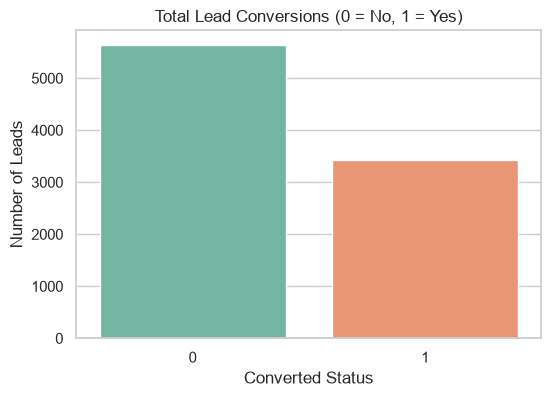

Overall Conversion Rate: 37.86%


In [29]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Converted', data=df, palette='Set2')
plt.title('Total Lead Conversions (0 = No, 1 = Yes)')
plt.xlabel('Converted Status')
plt.ylabel('Number of Leads')
plt.show()

# Print the exact percentage. sum 1's for converted, len for total 1s + 0s
conversion_rate = (sum(df['Converted'])/len(df['Converted'].index))*100
print(f"Overall Conversion Rate: {round(conversion_rate, 2)}%")

C:\Users\astin\AppData\Local\Temp\ipykernel_25804\828582766.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Converted', y='Total Time Spent on Website', data=df, palette='Set2')


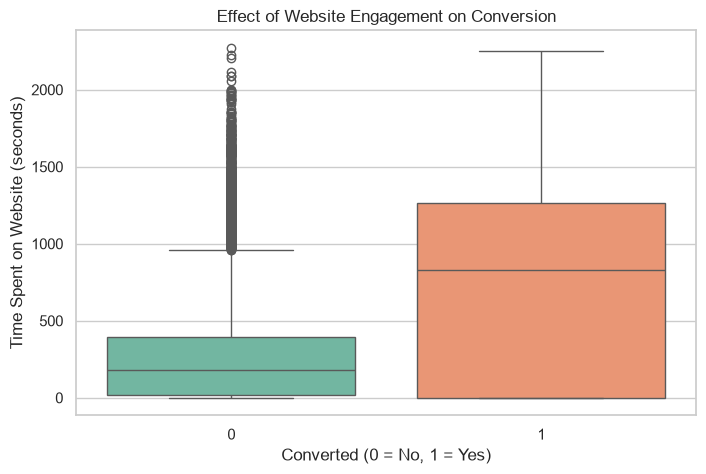

In [30]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Converted', y='Total Time Spent on Website', data=df, palette='Set2')
plt.title('Effect of Website Engagement on Conversion')
plt.xlabel('Converted (0 = No, 1 = Yes)')
plt.ylabel('Time Spent on Website (seconds)')
plt.show()

Median time spent for leads who converted (1) is ~800 seconds or over 13 minutes. The median for those non converted (0) is lower, around 20 seconds (3 mins).

Interquartile - large organge box for (1) shows bulk of successful converstaion are spending a significant time engaging with the site vs smaller (0) box for time on site

Outliers - may be tabs left open

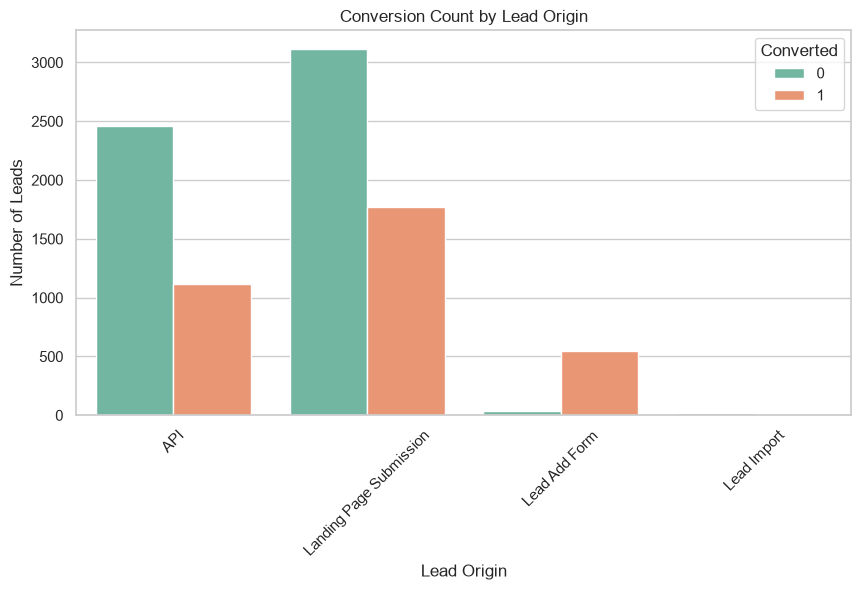

In [31]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Lead Origin', hue='Converted', data=df, palette='Set2')
plt.title('Conversion Count by Lead Origin')
plt.xlabel('Lead Origin')
plt.ylabel('Number of Leads')
plt.xticks(rotation=45)
plt.show()

landing page brings in the highest # of enrollments, but also largest non-converted leads. converstion around 30-40%

Lead Add Form - smaller volume but converstion rate is great. Almost all who enters through this form converts. High quality lead channel. Referral? transfer partner? in person event?

API Leads - 3rd party leads, poorer conversion. almost double # of non-converts to converts

In [33]:
# 1. Automatically identify all categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

# 2. Create the dummy variables, dropping the first category to avoid multicollinearity
# Setting dtype=int so the output is 1s and 0s, not True/False
dummy_df = pd.get_dummies(df[cat_cols], drop_first=True, dtype=int)

# 3. Attach the new dummy columns to original dataframe
df = pd.concat([df, dummy_df], axis=1)

# 4. Drop the original text columns since model cannot read
df = df.drop(columns=cat_cols)

# 5. See new size of dataset
print(f"New dataset shape: {df.shape}")

#making a col for each text category, 37 to 164 cols

New dataset shape: (9074, 164)


C:\Users\astin\AppData\Local\Temp\ipykernel_25804\2848501101.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate the target variable from features
X = df.drop('Converted', axis=1)
y = df['Converted']

# 2. Split the data (70% for training, 30% for testing)
# random_state to get same split each time
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=100)

# 3. scaler
scaler = StandardScaler()

# 4. Applying the scaler only to original numerical columns, not the 0/1 dummy columns
num_cols = ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# 5. Display scaled numerical columns to verify
print(X_train[num_cols].head())

      TotalVisits  Total Time Spent on Website  Page Views Per Visit
3009    -0.284595                    -0.160255             -0.179666
1012    -0.284595                    -0.540048             -0.179666
9226    -0.671384                    -0.888650             -1.132538
4750    -0.284595                     1.643304             -0.179666
7987     0.295588                     2.017593              0.058552


Negative values show prospective student spent less than the avg whlie positive reprepsents above avg engagement

163 cols will cause overfitting

use RFE to score variables and drop weakest (setting to find top 15).

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

# 1. Initialize the base logistic regression algorithm
logreg = LogisticRegression(max_iter=1000)

# 2. Set up RFE to find top 15 predictive features
rfe = RFE(estimator=logreg, n_features_to_select=15)

# 3. Train RFE on your scaled training data
rfe = rfe.fit(X_train, y_train)

# 4. Extract and print the names of winning columns
top_features = X_train.columns[rfe.support_]
print("Top 15 Predictors:")
for feature in top_features:
    print(f"- {feature}")

Top 15 Predictors:
- Lead Source_Welingak Website
- Do Not Email_Yes
- Last Activity_SMS Sent
- What matters most to you in choosing a course_Not Provided
- Tags_Busy
- Tags_Closed by Horizzon
- Tags_Lost to EINS
- Tags_Not Provided
- Tags_Ringing
- Tags_Will revert after reading the email
- Tags_invalid number
- Tags_switched off
- Tags_wrong number given
- Last Notable Activity_Modified
- Last Notable Activity_Olark Chat Conversation


In [36]:
# 1. Filter the training data to include the top 15 features
X_train_final = X_train[top_features]

# 2. Train the final logistic regression model
final_model = LogisticRegression(max_iter=1000)
final_model.fit(X_train_final, y_train)

# 3. Clean table to view how each feature impacts conversion
coefficients = pd.DataFrame({
    'Feature': top_features,
    'Coefficient (Impact)': final_model.coef_[0]
}).sort_values(by='Coefficient (Impact)', ascending=False)

print(coefficients)

                                              Feature  Coefficient (Impact)
6                                   Tags_Lost to EINS              6.964840
5                             Tags_Closed by Horizzon              6.593053
9            Tags_Will revert after reading the email              5.899541
7                                   Tags_Not Provided              3.003268
2                              Last Activity_SMS Sent              2.109176
0                        Lead Source_Welingak Website              1.930535
4                                           Tags_Busy              1.641194
14      Last Notable Activity_Olark Chat Conversation             -1.044287
1                                    Do Not Email_Yes             -1.241132
12                            Tags_wrong number given             -1.306688
13                     Last Notable Activity_Modified             -1.433388
11                                  Tags_switched off             -1.860130
10          

In [37]:
# 1. Filter the unseen test data to match the 15 features
X_test_final = X_test[top_features]

# 2. Predict the probability of conversion
# The [:, 1] isolates the probability of a "1"
y_test_pred_prob = final_model.predict_proba(X_test_final)[:, 1]

# 3. Clean dataframe to compare new scores against what actually happened
lead_scores = pd.DataFrame({'Actual_Converted': y_test, 'Conversion_Prob': y_test_pred_prob})

# 4. Multiply by 100 to generate the final 0-100 Lead Score
lead_scores['Lead_Score'] = round(lead_scores['Conversion_Prob'] * 100, 1)

# 5. Review a sample of the scored leads
print(lead_scores.head(10))

      Actual_Converted  Conversion_Prob  Lead_Score
3271                 0         0.122359        12.2
1490                 1         0.966135        96.6
7936                 0         0.122359        12.2
4216                 1         0.931569        93.2
3830                 0         0.122359        12.2
1800                 1         0.966135        96.6
6507                 0         0.071031         7.1
4821                 0         0.012024         1.2
4223                 1         0.995765        99.6
4714                 0         0.215094        21.5


In [38]:
# Define a list of potential Lead Score cutoffs to test
cutoffs = [40, 50, 60, 70, 80, 85, 90, 95]

print("Simulating Lead Score Cutoffs for the Admissions Team:\n")

for cutoff in cutoffs:
    # Filter for only the leads that meet or exceed the current cutoff
    targeted_leads = lead_scores[lead_scores['Lead_Score'] >= cutoff]
    
    # Ensure there are actually leads in this group to avoid division errors
    if len(targeted_leads) > 0:
        # Calculate the conversion rate (Precision) for this specific group
        conversion_rate = targeted_leads['Actual_Converted'].mean() * 100
        
        # Calculate how much of the total pipeline this cuts out
        pipeline_pct = (len(targeted_leads) / len(lead_scores)) * 100
        
        print(f"Cutoff Score: {cutoff}+")
        print(f"- Leads for Sales to Call: {len(targeted_leads)} ({round(pipeline_pct, 1)}% of total pipeline)")
        print(f"- Resulting Conversion Rate: {round(conversion_rate, 1)}%\n")

Simulating Lead Score Cutoffs for the Admissions Team:

Cutoff Score: 40+
- Leads for Sales to Call: 992 (36.4% of total pipeline)
- Resulting Conversion Rate: 90.2%

Cutoff Score: 50+
- Leads for Sales to Call: 981 (36.0% of total pipeline)
- Resulting Conversion Rate: 90.4%

Cutoff Score: 60+
- Leads for Sales to Call: 899 (33.0% of total pipeline)
- Resulting Conversion Rate: 92.8%

Cutoff Score: 70+
- Leads for Sales to Call: 812 (29.8% of total pipeline)
- Resulting Conversion Rate: 95.2%

Cutoff Score: 80+
- Leads for Sales to Call: 782 (28.7% of total pipeline)
- Resulting Conversion Rate: 96.4%

Cutoff Score: 85+
- Leads for Sales to Call: 782 (28.7% of total pipeline)
- Resulting Conversion Rate: 96.4%

Cutoff Score: 90+
- Leads for Sales to Call: 714 (26.2% of total pipeline)
- Resulting Conversion Rate: 97.6%

Cutoff Score: 95+
- Leads for Sales to Call: 607 (22.3% of total pipeline)
- Resulting Conversion Rate: 98.0%



This project built a logistic regression model to streamline the student enrollment funnel by predicting exactly which prospective leads are most likely to convert. After cleaning historical inquiry data and isolating the top behavioral signals (such as direct SMS engagement and active CRM tags) the model successfully generated a reliable 0-100 Lead Score for every prospect, while also identifying that a student's refusal to answer basic form questions was the strongest indicator of a dead lead.

Simulating different score thresholds revealed a efficient strategy for optimizing the admissions pipeline. By setting the cutoff score at 40, the model safely eliminates nearly 64% of the raw, low-intent inquiries from the daily call queue. For the remaining 36% of leads that the team actually contacts, the resulting conversion rate jumps to 90.2%, easily surpassing the 80% target yield and allowing the team to shift away from volume dialing to focus exclusively on high value prospects.